In [4]:
import kwant
from matplotlib import pyplot as plt
from scipy.constants import physical_constants
import numpy as np

In [7]:
m_el = physical_constants['electron mass'][0]
m_eff = 0.067
eV = physical_constants['electron volt'][0]
hbar = physical_constants['Planck constant over 2 pi'][0]

In [8]:
a = 10 * 1e-9 # in nm
t = hbar**2 / (2 * m_el * m_eff * a**2) / eV
print(t)

0.005686540281567095


In [9]:
W = 40
L = 60

In [10]:
# We create system/build
sys = kwant.Builder()
latt = kwant.lattice.square(a, norbs = 1)

In [42]:
# We create potential/gaussian
R0 = 10 *a
def potential(x, y, U):
    return np.exp(-((L * a / 2 - x)**2 + (W * a / 2 - y)**2) / R0**2)

In [43]:
def onsite(site, U):
    x, y = site.pos
    return 4 * t + potential(x, y, U)

In [44]:
sys[(latt(x, y) for x in range(0, L) for y in range(0, W))] = onsite

In [45]:
sys[[latt.neighbors()]] = -t

In [46]:
# We add leads on the sides
leadl = kwant.Builder(kwant.TranslationalSymmetry((-a, 0)))
leadr = kwant.Builder(kwant.TranslationalSymmetry((a, 0)))

In [47]:
leadl[(latt(0, y) for y in range(0, W))] = onsite
leadr[(latt(0, y) for y in range(0, W))] = onsite

In [48]:
leadl[latt.neighbors()] = -t
leadr[latt.neighbors()] = -t

In [49]:
sys.attach_lead(leadl)
sys.attach_lead(leadr)

[]

In [50]:
sysf = sys.finalized()

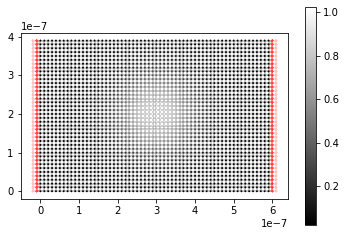

In [51]:
kwant.plot(sysf, site_color = lambda site : sysf.hamiltonian(site, site, params = dict(U = 10)));

/tmp/ipykernel_18843/1861749705.py:1: RuntimeWarning: The plotted data contains 0.88% of values overflowing upper limit 0.960102 
  kwant.plotter.map(sys, lambda s: onsite(s, 5));


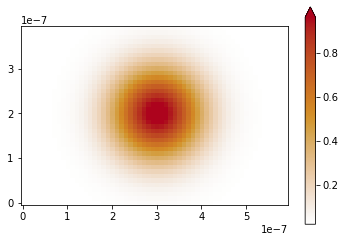

In [52]:
kwant.plotter.map(sys, lambda s: onsite(s, 5));